# 1.1.3 Splitter Check

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.generators import Math2DGenerator
from src.noise import AbsoluteGaussianNoise
from src.shadows import CircularShadow, BandShadow
from src.splitter import GapSplitter
from src.visualization import plot_split_distribution

### 1. Datuak Sortu

In [2]:
gen = Math2DGenerator(lambda x: x, seed=42)
df = gen.generate(
    n_samples=500, 
    x_range=(0, 20), 
    noise_strategy=AbsoluteGaussianNoise(0.5)
)
print(f"Total Datuak: {len(df)}")

Total Datuak: 500


### 2. Itzala Definitu

In [3]:
shadow = CircularShadow(x_0=10, y_0=10, r=3.0)

### 3. Splitter Exekutatu

In [4]:
splitter = GapSplitter(test_size=0.2, random_state=42)
result = splitter.split(df, shadow)

### 4. Emaitzak eta Estatistikak

In [5]:
n_total = len(df)
n_train = len(result.X_train)
n_test_vis = len(result.X_test_visible)
n_test_shadow = len(result.X_test_shadow)

print("-" * 40)
print(f"Total Datos:   {n_total}")
print(f"Train Set:     {n_train} ({n_train/n_total*100:.1f}%) -> Urdina (Entrenamendua)")
print(f"Test Visible:  {n_test_vis} ({n_test_vis/n_total*100:.1f}%) -> Ziana (Test Normala)")
print(f"Test Shadow:   {n_test_shadow} ({n_test_shadow/n_total*100:.1f}%) -> Gorria (Hutsunea)")
print("-" * 40)
print(f"Test Global:   {len(result.X_test_global)} (Visible + Shadow)")

----------------------------------------
Total Datos:   500
Train Set:     315 (63.0%) -> Urdina (Entrenamendua)
Test Visible:  79 (15.8%) -> Ziana (Test Normala)
Test Shadow:   106 (21.2%) -> Gorria (Hutsunea)
----------------------------------------
Test Global:   185 (Visible + Shadow)


### 5. Visualización (Plot)

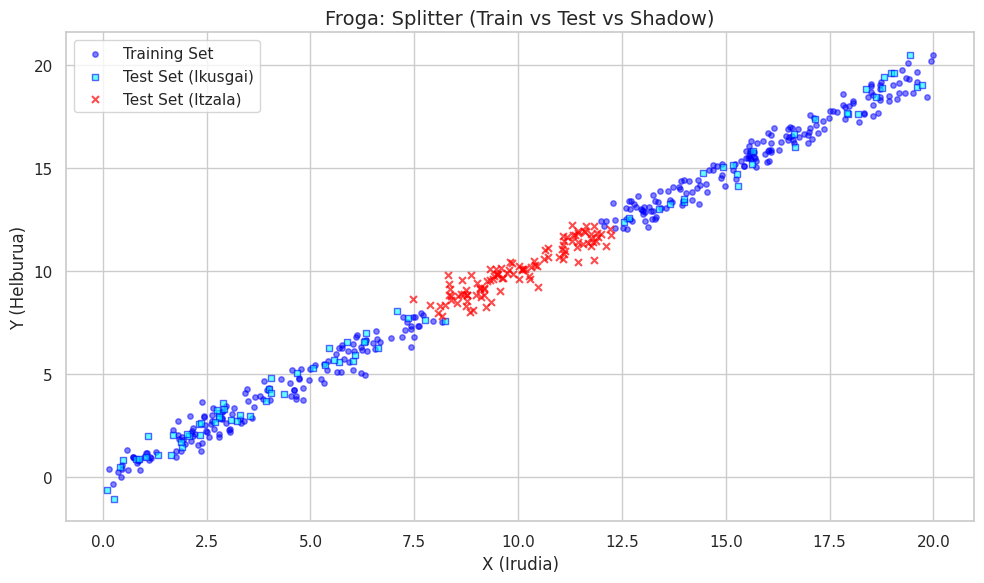

In [6]:
plot_split_distribution(result, title="Froga: Splitter (Train vs Test vs Shadow)")

### 6. Balidazio Multzoa
Etorkizunean (Sare Neuronaletarako) "Validation Set" bat beharko dugu.
Ohikoena da `X_train` hartu eta berriro zatitzea.
Hemen ikusten da nola egingo genukeen azpibanaketa hor

Jatorrizko Train: 315
-> Train Final:   252 (Urdina)
-> Validation:    63 (Berdea - Doikuntzarako)


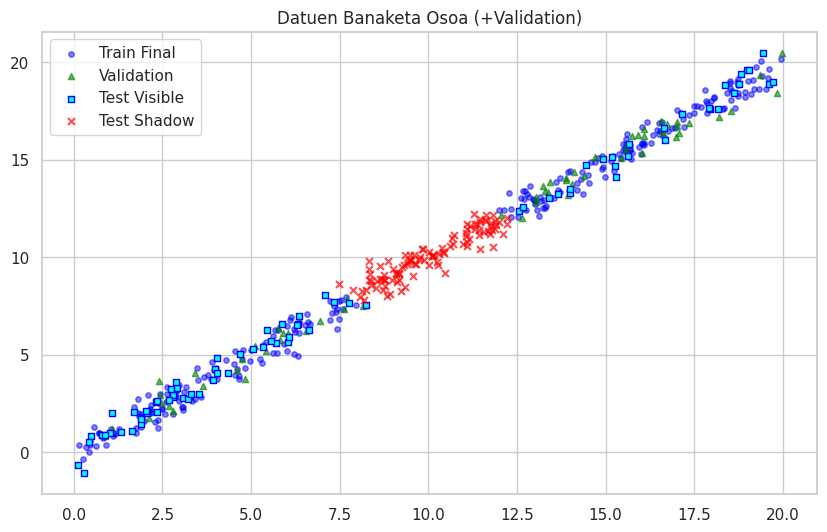

In [7]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    result.X_train, 
    result.y_train, 
    test_size=0.2, 
    random_state=42
)

print(f"Jatorrizko Train: {len(result.X_train)}")
print(f"-> Train Final:   {len(X_train_final)} (Urdina)")
print(f"-> Validation:    {len(X_val)} (Berdea - Doikuntzarako)")

plt.figure(figsize=(10, 6))
plt.scatter(X_train_final, y_train_final, color='blue', alpha=0.5, label='Train Final', s=15)
plt.scatter(X_val, y_val, color='green', alpha=0.6, label='Validation', s=20, marker='^')
plt.scatter(result.X_test_visible, result.y_test_visible, color='cyan', edgecolor='blue', label='Test Visible', s=20, marker='s')
plt.scatter(result.X_test_shadow, result.y_test_shadow, color='red', alpha=0.7, label='Test Shadow', s=25, marker='x')

plt.title("Datuen Banaketa Osoa (+Validation)")
plt.legend()
plt.show()